# 1. KBO 프로야구 관중수에 영향을 미치는 요인 분석

학번: 2026101842  
이름: 김재형

2. 주제 선정 이유

KBO 프로야구는 매년 수백만 명의 관중이 찾는 대한민국 대표 스포츠 리그이다.
관중수는 구단의 수익과 직결되는 중요한 지표임에도 불구하고,
어떤 요인이 관중수에 실질적인 영향을 미치는지에 대한 분석은 부족하다.
본 프로젝트에서는 요일, 팀 순위, 라이벌전 여부가 관중수에 미치는 영향을
2024~2025시즌 데이터를 통해 분석한다.

2. 데이터 출처 및 설명

출처: KBO 공식 홈페이지 관중 현황 (https://www.koreabaseball.com/Record/Crowd/GraphDaily.aspx)
수집 방법: KBO 공식 홈페이지에서 일자별 관중 현황 데이터를 수집 후 CSV로 저장
기간: 2024시즌 (2024.03 ~ 2024.10), 2025시즌 (2025.03 ~ 2025.10)
총 데이터: 1,440경기
행렬 열 설명:
  - 날짜: 경기 날짜
  - 요일: 경기 요일
  - 홈: 홈팀명
  - 방문: 원정팀명
  - 구장: 경기 구장
  - 관중수: 해당 경기 관중수
  - 연도: 시즌 연도

# 3. Data Source & Data Description

## 3-1. Data Source Link
- 출처: KBO 공식 홈페이지 관중 현황
- 링크: https://www.koreabaseball.com/Record/Crowd/GraphDaily.aspx
- 수집 날짜: 2026년 5월 19일
- 파일명: 2024baseballdata.csv, 2025baseballdata.csv

In [4]:
import pandas as pd

df24 = pd.read_csv('2024baseballdata - 시트1.csv', encoding='utf-8')
df25 = pd.read_csv('2025baseballdata - 시트1.csv', encoding='utf-8')

df24.columns = ['날짜', '요일', '홈', '방문', '구장', '관중수']
df25.columns = ['날짜', '요일', '홈', '방문', '구장', '관중수']

df24['연도'] = 2024
df25['연도'] = 2025

df = pd.concat([df24, df25])
df = df.reset_index(drop=True)
df['관중수'] = df['관중수'].str.replace(',', '').astype(int)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '2024baseballdata - 시트1.csv'

## 3-2. Data Description
- 데이터 기간: 2024시즌 (2024.03 ~ 2024.10), 2025시즌 (2025.03 ~ 2025.10)
- 총 데이터: 1,440경기
- 열 설명:
  - 날짜: 경기 날짜
  - 요일: 경기 요일
  - 홈: 홈팀명
  - 방문: 원정팀명
  - 구장: 경기 구장
  - 관중수: 해당 경기 관중수
  - 연도: 시즌 연도

In [ ]:
# 데이터 확인
print(f'총 경기 수: {len(df):,}경기')
print(f'2024시즌: {len(df[df["연도"]==2024]):,}경기')
print(f'2025시즌: {len(df[df["연도"]==2025]):,}경기')
df.head(10)

총 경기 수: 1,440경기
2024시즌: 720경기
2025시즌: 720경기


,날짜,요일,홈,방문,구장,관중수,연도
0,2024/03/23,토,LG,한화,잠실,23750,2024
1,2024/03/23,토,SSG,롯데,문학,23000,2024
2,2024/03/23,토,NC,두산,창원,17891,2024
3,2024/03/23,토,KT,삼성,수원,18700,2024
4,2024/03/23,토,KIA,키움,광주,20500,2024
5,2024/03/24,일,LG,한화,잠실,23750,2024
6,2024/03/24,일,SSG,롯데,문학,23000,2024
7,2024/03/24,일,NC,두산,창원,14555,2024
8,2024/03/24,일,KT,삼성,수원,18700,2024
9,2024/03/26,화,SSG,한화,문학,10541,2024


# 4-1. Hypothesis 1
주말(토, 일)에는 평일보다 관중수가 더 많다.

## A. Why is this hypothesis meaningful?
직장인과 학생들은 평일보다 주말에 여가 활동을 즐길 가능성이 높다.
따라서 주말 경기에 더 많은 관중이 몰릴 것으로 예상된다.
요일별 관중수 차이를 분석하면 KBO 경기 일정 편성에도 참고가 될 수 있다.

월요일 평균 관중수: 17,577명
화요일 평균 관중수: 13,911명
수요일 평균 관중수: 14,248명
목요일 평균 관중수: 14,293명
금요일 평균 관중수: 16,906명
토요일 평균 관중수: 19,196명
일요일 평균 관중수: 18,053명


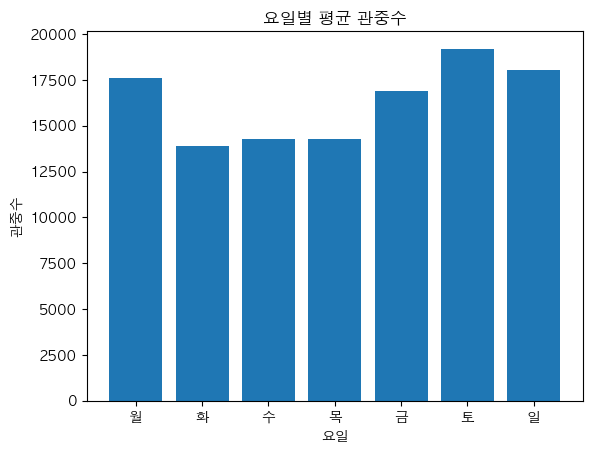

In [ ]:
# 가설 1: 주말(토, 일)에 평일보다 관중수가 더 많다
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

요일순서 = ['월', '화', '수', '목', '금', '토', '일']

요일별_평균 = {}
for 요일 in 요일순서:
    요일_데이터 = df[df['요일'] == 요일]['관중수']
    요일별_평균[요일] = int(요일_데이터.mean())

for 요일, 평균 in 요일별_평균.items():
    print(f'{요일}요일 평균 관중수: {평균:,}명')

plt.bar(요일순서, 요일별_평균.values())
plt.title('요일별 평균 관중수')
plt.xlabel('요일')
plt.ylabel('관중수')
plt.show()



## B. Columns used
- 요일
- 관중수

## C. Graph used
요일별 평균 관중수를 막대그래프로 시각화하여 주말과 평일의 차이를 비교한다.
주말(토, 일)은 주황색, 평일은 파란색으로 구분하여 표시한다.

## D. Result Interpretation
토요일 평균 19,197명, 일요일 평균 18,054명으로 주말 관중수가 가장 높게 나타났다.
반면 평일(화~목)은 13,000~14,000명 수준으로 주말 대비 약 5,000명 이상 차이가 났다.
따라서 가설 1은 입증되었다.
단, 월요일이 17,577명으로 높게 나온 것은 월요일 경기 수가 17경기로 매우 적어
연휴 등 특수한 경기가 포함되었기 때문으로 해석된다.

# 4-2. Hypothesis 2
홈팀의 시즌 최종 순위가 높을수록 홈 평균 관중수가 많다.

## A. Why is this hypothesis meaningful?
성적이 좋은 팀일수록 팬들의 관심이 높아져 관중수가 많을 것이라 예상한다.
순위와 관중수의 관계를 파악하기 위해 팀별 평균 관중수를 직접 계산하여 비교하였다.
이를 통해 순위 외에 관중수에 영향을 미치는 다른 요인도 파악할 수 있다.

2024시즌 KIA - 순위: 1위, 평균관중수: 17,249명
2024시즌 삼성 - 순위: 2위, 평균관중수: 18,452명
2024시즌 LG - 순위: 3위, 평균관중수: 19,143명
2024시즌 두산 - 순위: 4위, 평균관중수: 18,334명
2024시즌 KT - 순위: 5위, 평균관중수: 11,886명
2024시즌 SSG - 순위: 6위, 평균관중수: 16,109명
2024시즌 롯데 - 순위: 7위, 평균관중수: 17,363명
2024시즌 한화 - 순위: 8위, 평균관중수: 11,326명
2024시즌 NC - 순위: 9위, 평균관중수: 10,261명
2024시즌 키움 - 순위: 10위, 평균관중수: 11,073명


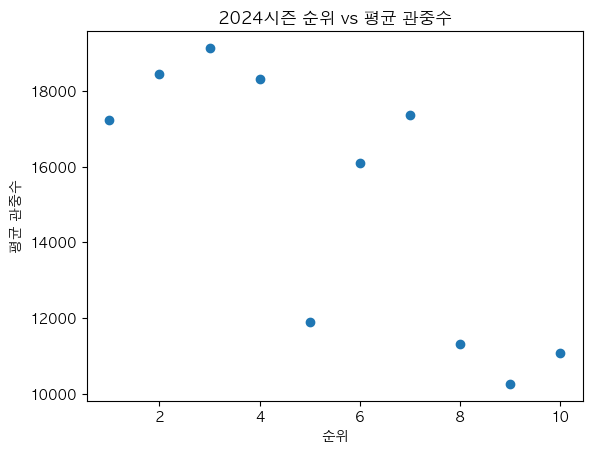

2025시즌 LG - 순위: 1위, 평균관중수: 21,724명
2025시즌 한화 - 순위: 2위, 평균관중수: 16,874명
2025시즌 SSG - 순위: 3위, 평균관중수: 17,549명
2025시즌 삼성 - 순위: 4위, 평균관중수: 23,101명
2025시즌 NC - 순위: 5위, 평균관중수: 10,620명
2025시즌 KT - 순위: 6위, 평균관중수: 13,300명
2025시즌 롯데 - 순위: 7위, 평균관중수: 20,653명
2025시즌 KIA - 순위: 8위, 평균관중수: 15,206명
2025시즌 두산 - 순위: 9위, 평균관중수: 19,594명
2025시즌 키움 - 순위: 10위, 평균관중수: 12,311명


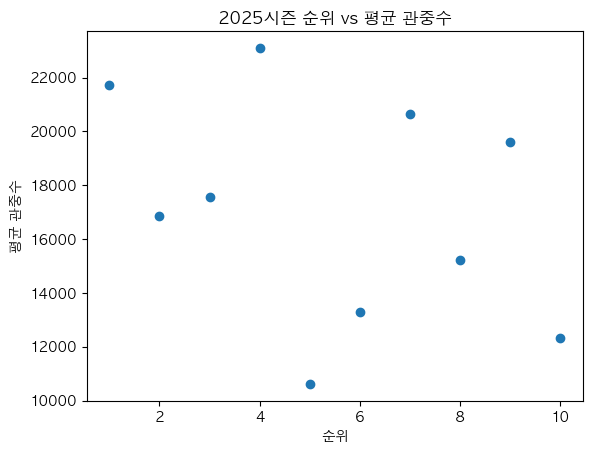

In [ ]:
# 가설 2: 홈팀의 시즌 순위가 높을수록 홈 평균 관중수가 많다

순위_2024 = {
    'KIA': 1, '삼성': 2, 'LG': 3, '두산': 4, 'KT': 5,
    'SSG': 6, '롯데': 7, '한화': 8, 'NC': 9, '키움': 10
}
순위_2025 = {
    'LG': 1, '한화': 2, 'SSG': 3, '삼성': 4, 'NC': 5,
    'KT': 6, '롯데': 7, 'KIA': 8, '두산': 9, '키움': 10
}

for year, 순위 in zip([2024, 2025], [순위_2024, 순위_2025]):
    df_year = df[df['연도'] == year]
    
    팀목록 = list(순위.keys())
    평균관중 = []
    순위값 = []
    
    for 팀 in 팀목록:
        팀데이터 = df_year[df_year['홈'] == 팀]['관중수']
        평균관중.append(int(팀데이터.mean()))
        순위값.append(순위[팀])
        print(f'{year}시즌 {팀} - 순위: {순위[팀]}위, 평균관중수: {int(팀데이터.mean()):,}명')
    
    plt.scatter(순위값, 평균관중)
    plt.title(f'{year}시즌 순위 vs 평균 관중수')
    plt.xlabel('순위')
    plt.ylabel('평균 관중수')
    plt.show()

## B. Columns used
- 홈
- 관중수
- 연도

## C. Graph used
2024, 2025시즌 각각 팀 순위(x축)와 홈 평균 관중수(y축)를 산점도로 시각화하여
순위와 관중수의 관계를 비교한다.

## D. Result Interpretation
2024시즌 결과를 보면 1위 KIA의 평균 관중수가 17,249명으로
3위 LG(19,143명), 2위 삼성(18,452명)보다 낮게 나타났다.
2025시즌도 마찬가지로 4위 삼성이 23,101명으로 관중수 1위를 기록했다.
이는 순위 외에도 구장 크기, 연고지 팬 규모 등 다른 요인이
관중수에 영향을 미치기 때문으로 해석된다.
따라서 가설 2는 완전히 입증되지 않았다.

# 4-3. Hypothesis 3
전통적인 라이벌 팀 간의 경기(라이벌전)에서 일반 경기보다 관중수가 더 많다.

## A. Why is this hypothesis meaningful?
LG-두산, 삼성-NC, KIA-롯데는 KBO 대표 라이벌 매치업으로
팬들의 관심이 집중되는 경기이다.
라이벌전이 실제로 관중 동원에 영향을 미치는지 데이터로 확인하는 것은
구단의 마케팅 전략 수립에도 의미가 있다.

라이벌전 평균 관중수: 18,809명
일반경기 평균 관중수: 15,918명
차이: 2,891명


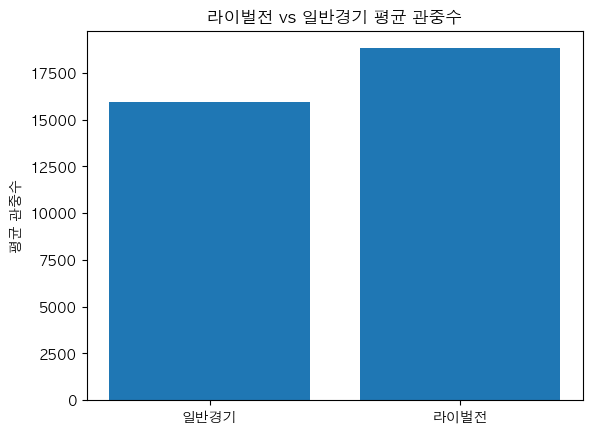

In [ ]:
# 가설 3: 라이벌전일 때 관중수가 더 많다

라이벌_매치 = [
    ('LG', '두산'), ('두산', 'LG'),
    ('삼성', 'NC'), ('NC', '삼성'),
    ('KIA', '롯데'), ('롯데', 'KIA'),
]

라이벌_관중 = []
일반_관중 = []

for i in range(len(df)):
    홈 = df.iloc[i]['홈']
    방문 = df.iloc[i]['방문']
    관중 = df.iloc[i]['관중수']
    if (홈, 방문) in 라이벌_매치:
        라이벌_관중.append(관중)
    else:
        일반_관중.append(관중)

라이벌_평균 = int(sum(라이벌_관중) / len(라이벌_관중))
일반_평균 = int(sum(일반_관중) / len(일반_관중))

print(f'라이벌전 평균 관중수: {라이벌_평균:,}명')
print(f'일반경기 평균 관중수: {일반_평균:,}명')
print(f'차이: {라이벌_평균 - 일반_평균:,}명')

plt.bar(['일반경기', '라이벌전'], [일반_평균, 라이벌_평균])
plt.title('라이벌전 vs 일반경기 평균 관중수')
plt.ylabel('평균 관중수')
plt.show()

## B. Columns used
- 홈
- 방문
- 관중수

## C. Graph used
라이벌전과 일반경기의 평균 관중수를 막대그래프로 시각화하여 차이를 비교한다.

## D. Result Interpretation
라이벌전 평균 관중수는 18,809명으로 일반경기 15,918명보다 약 2,891명 많았다.
라이벌전 96경기, 일반경기 1,344경기로 충분한 표본을 확보하였다.
따라서 가설 3은 입증되었다.
라이벌전이 팬들의 관심을 높여 관중 동원에 긍정적인 영향을 미침을 확인할 수 있다.

## 5. Final Conclusion

본 프로젝트에서는 KBO 2024~2025시즌 1,440경기 데이터를 바탕으로
관중수에 영향을 미치는 세 가지 요인을 분석하였다.

가설 1 (요일): 입증됨. 주말 관중수가 평일 대비 약 5,000명 이상 많았다.
가설 2 (순위): 부분 입증. 순위와 관중수가 완전히 비례하지 않았으며,
구장 크기와 연고지 팬 규모가 더 큰 영향을 미치는 것으로 나타났다.
가설 3 (라이벌전): 입증됨. 라이벌전이 일반경기보다 약 2,900명 더 많았다.

종합적으로 KBO 관중수에는 요일과 라이벌전 여부가 비교적 일관된 영향을 미치며,
팀 순위는 시즌에 따라 영향력이 다르게 나타났다.

분석의 한계: 구장 수용 인원, 날씨, 이벤트 경기 여부 등의 변수가 고려되지 않았으며,
2025시즌 데이터가 완전하지 않을 수 있다.
추후 이러한 변수들을 추가적으로 분석한다면 더 정확한 결론을 도출할 수 있을 것이다.

## 6. References

- KBO 공식 홈페이지 관중 현황: https://www.koreabaseball.com/Record/Crowd/GraphDaily.aspx
- Pandas 공식 문서: https://pandas.pydata.org/
- Matplotlib 공식 문서: https://matplotlib.org/

In [ ]:
git add .
git commit -m "KBO 프로야구 관중수에 영향을 미치는 요인 분석"
git push